# IE4424 Lab Part1\_Object\_Detection

## Acknowledgment
This lab experiment is modified based on Faster R-CNN.

You can check the Faster R-CNN repo at https://github.com/rbgirshick/py-faster-rcnn.

## 1. Training an object detector
This guide provides a step-by-step approach to train an object detection model using Faster R-CNN. It focuses on detecting cats and dogs using a dataset derived from COCO including the size, location and category of each object in the images. By following this guide, you will gain an understanding of the process and be able to reproduce the results independently.

The dataset is structured as follows:

- Training Set: `train/` with annotations in `instances_train.json`
- Validation Set: `val/` with annotations in `instances_val.json`

We will do the following steps in order:

1) Load and normalize the training and testing datasets using ``torchvision``
   
2) Define an object detection model

3) Define a loss function

4) Train the network on the training data

5) Test the network on the test data

In [ ]:
pip install -r requirements.txt

In [1]:
import os
import json
import time
import numpy as np
from statistics import mean
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.interpolate import make_interp_spline
from PIL import Image
from thop import profile
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms.v2 as T
import torchvision.models as models
import torchvision.models.detection as detection
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchinfo import summary
from pycocotools.cocoeval import COCOeval
from pycocotools.coco import COCO
from custom_dataset import CocoDataset  # Defined in custom_dataset.py
# Define paths
data_path = "data"
annotation_path = os.path.join(data_path, "annotations")
train_annotation_file = os.path.join(annotation_path, "instances_train.json")
val_annotation_file = os.path.join(annotation_path, "instances_val.json")
train_data_path = os.path.join(data_path, "train")
val_data_path = os.path.join(data_path, "val")
model_path_default = "faster_rcnn_model.pth"
model_path_mobilenet_v3_large_fpn = "faster_rcnn_model_mobilenet_v3_large_fpn.pth"
model_path_resnet50_fpn_v2 = "faster_rcnn_model_resnet50_fpn_v2.pth"
model_path_resnet50 = "faster_rcnn_model_resnet50_fpn.pth"

### 1.1 Defining custom collate function

The `collate_fn` function separates images and targets into lists, ensuring flexible batch processing for object detection models.

In [2]:
def collate_fn(batch):
    images, targets, img_id = zip(*batch)
    return list(images), list(targets), list(img_id)

### 1.2 Defining transform

The `transform` applies a simple preprocessing step, converting images to tensors using `T.ToImage()`, which normalizes pixel values to get faster convergence.

In [3]:
transform1 = T.Compose([
    # Convert PIL image to tensor (fix Normalize error)
    T.ToImage(),  # Convert PIL image to Tensor (C, H, W) format

    # Color augmentations (only affect image)
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.RandomAdjustSharpness(sharpness_factor=2, p=0.2),
    T.RandomApply([T.GaussianBlur(kernel_size=(3, 3))], p=0.1),

    # Bounding Box Processing
    T.ConvertBoundingBoxFormat("xyxy"),  # Ensure bbox remains in xyxy format

    # Normalize image
    T.ToDtype(torch.float32, scale=True),  # Convert image to float32 tensor and scale pixels to [0,1]
])
transform2 = T.Compose([
    # Convert PIL image to tensor (fix Normalize error)
    T.ToImage(),  # Convert PIL image to Tensor (C, H, W) format

    # Bounding Box Processing
    T.ConvertBoundingBoxFormat("xyxy"),  # Ensure bbox remains in xyxy format

    # Normalize image
    T.ToDtype(torch.float32, scale=True),  # Convert image to float32 tensor and scale pixels to [0,1]
])

### 1.3 Loading datasets

We load the training and validation datasets using the `CocoDataset` class with defined transformations. Then, we initialize data loaders to efficiently handle batching, shuffling, and pre-processing for training and validation.

In [4]:
train_dataset = CocoDataset(train_annotation_file, train_data_path, transforms=transform1)
val_dataset = CocoDataset(val_annotation_file, val_data_path, transforms=transform2)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0, pin_memory=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=True, collate_fn=collate_fn)

### 1.4 Visualizing the training data

We visualize the images and the groundtruth bounding boxes in the images.

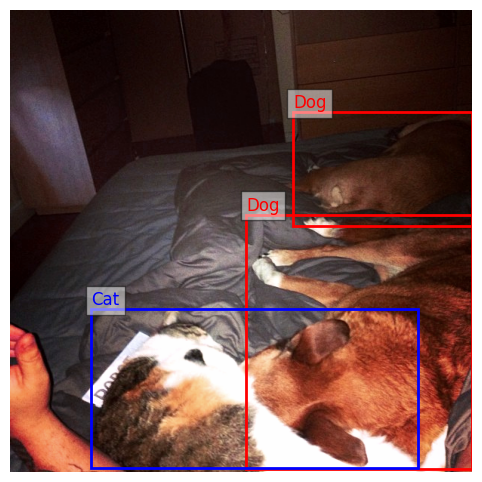

Displayed data for image 543719.jpg


In [5]:
def visualize_data(image, annotation, img_id):
    # Visualizes an image with its corresponding bounding boxes and labels.
    fig, ax = plt.subplots(1, figsize=(8, 6))  # Create a figure and axis for visualization
    ax.imshow(image)  # Display the image
    # Define label colors and names (Cat: Blue, Dog: Red)
    label_colors = {17: "blue", 18: "red"}
    label_names = {17: "Cat", 18: "Dog"}
    # Iterate through bounding boxes and labels
    for box, label in zip(annotation["boxes"], annotation["labels"]):
        box = box.cpu().numpy()  # Convert tensor to numpy array
        if label.item() in label_names:  # Check if label is known
            color = label_colors[label.item()]  # Get corresponding color
            # Create a rectangle for the bounding box
            rect = patches.Rectangle(
                (box[0], box[1]), box[2] - box[0], box[3] - box[1],  # Convert xyxy → xywh
                linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)  # Add rectangle to the image
            # Add label text above the bounding box
            ax.text(box[0], box[1] - 5, label_names[label.item()], color=color, fontsize=12,
                    bbox=dict(facecolor="white", alpha=0.5))  # Background for readability
    plt.axis("off")  # Hide axes
    plt.show()  # Display the image
    print(f"Displayed data for image {img_id}.jpg")  # Print image ID

# Iterate through the training dataset and visualize one sample
for batch_idx, (image, target, img_id) in enumerate(train_loader):
    if batch_idx == 1:  # Visualize the first sample only
        visualize_data(image[0].cpu().permute(1, 2, 0), target[0], img_id[0])
        break  # Exit after visualizing one image

### 1.5 Setting device

The GPU is set as the computing device if available, enabling faster processing for training and validation.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### 1.6 Loading model

We load a pre-trained Faster R-CNN model with a ResNet-50 FPN backbone, freeze its backbone layers to preserve pre-trained features, and move it to the selected device for training and validation.

In [7]:
model = detection.fasterrcnn_resnet50_fpn(weights=detection.FasterRCNN_ResNet50_FPN_Weights.COCO_V1)
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

## Exercise 1.1 Visualizing network structure using Torchsummury

Visualize the network structure and complete Exercise 1.1 in the answer sheet.

### E1.1.1 Visualize the network before freezing backbone

In [8]:
summary(model, input_size=(8, 3, 800, 800), depth=3, col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
FasterRCNN                                              [8, 3, 800, 800]          [0, 4]                    --                        Partial
├─GeneralizedRCNNTransform: 1-1                         [8, 3, 800, 800]          [8, 3, 800, 800]          --                        --
├─BackboneWithFPN: 1-2                                  [8, 3, 800, 800]          [8, 256, 13, 13]          --                        Partial
│    └─IntermediateLayerGetter: 2-1                     [8, 3, 800, 800]          [8, 2048, 25, 25]         --                        Partial
│    │    └─Conv2d: 3-1                                 [8, 3, 800, 800]          [8, 64, 400, 400]         (9,408)                   False
│    │    └─FrozenBatchNorm2d: 3-2                      [8, 64, 400, 400]         [8, 64, 400, 400]         --                        --
│    │    └─ReLU

### E1.1.2 Visualize the network after freezing backbone

The backbone CNNs are pre-trained on large-scale Imagenet dataset, so we freeze the backbone weight to preserve the knowledge gained in pre-training.

In [ ]:
for param in model.backbone.parameters():
    param.requires_grad = False
summary(model, input_size=(8, 3, 800, 800), depth=3, col_names=["input_size", "output_size", "num_params", "trainable"])

### 1.7 Defining optimizer

We use the AdamW optimizer for to enhance training stability.

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(),  # Parameters of the model to be optimized
                              lr=5e-4,  # Learning rate (0.0005)
                              weight_decay=1e-4,  # L2 weight decay (regularization) to prevent overfitting
                              betas=(0.9, 0.999)) # Beta values for computing running averages of gradients (β1, β2)

### 1.8 Defining loss function

We use the cross-entropy loss and smooth L1 loss for training.

In [ ]:
def loss_fn(loss_dict, weight_cls=1.0, weight_box=1.0, weight_rpn_cls=1.0, weight_rpn_box=1.0):
    # Extract losses from dictionary, or default to zero if missing
    loss_cls = loss_dict.get("loss_classifier", torch.tensor(0.0, requires_grad=True)) * weight_cls  # Classification loss
    loss_box = loss_dict.get("loss_box_reg", torch.tensor(0.0, requires_grad=True)) * weight_box  # Bounding box regression loss
    loss_rpn_cls = loss_dict.get("loss_objectness", torch.tensor(0.0, requires_grad=True)) * weight_rpn_cls  # RPN classification loss
    loss_rpn_box = loss_dict.get("loss_rpn_box_reg", torch.tensor(0.0, requires_grad=True)) * weight_rpn_box  # RPN box regression loss
    total_loss = loss_cls + loss_box + loss_rpn_cls + loss_rpn_box  # Compute total loss
    return total_loss  # Return the computed total loss

### 1.9 Train the network

We loop over our data iterator, and feed the inputs to the network and optimize the parameters.

In [ ]:
def train_model(model, train_loader, optimizer, num_epochs=30, model_path=model_path_default):
    # Train the model using the provided training data loader and optimizer.
    model.train()  # Set the model to training mode
    loss_list=[]  # List to store loss values
    for epoch in range(num_epochs):  # Loop over epochs
        start_time = time.time()  # Record start time of the epoch
        for batch_idx, (images, targets, _) in enumerate(train_loader):  # Iterate over training batches
            torch.cuda.synchronize()  # Synchronize CUDA operations
            # Move images and targets to the appropriate device (GPU)
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            optimizer.zero_grad()  # Reset gradients before backpropagation
            # Forward pass: Compute model output and loss
            loss_dict = model(images, targets)
            losses = loss_fn(loss_dict, weight_cls=1.0, weight_box=1.0, weight_rpn_cls=1.0, weight_rpn_box=1.0)
            # Backward pass: Compute gradients and update model parameters
            losses.backward()
            optimizer.step()
            # Store loss value
            loss_list.append(losses.item())  # Store loss
            print(f"Epoch {epoch + 1}/{num_epochs}, Batch {batch_idx + 1}/{len(train_loader)}, Loss: {losses.item():.4f}")
        print(f"Epoch {epoch + 1}/{num_epochs} completed in {time.time() - start_time:.2f} seconds")  # Print epoch completion time
    torch.save(model.state_dict(), model_path)  # Save trained model parameters
    return loss_list  # Return loss history

In [ ]:
loss_list = train_model(model, train_loader, optimizer, model_path = model_path_resnet50)

## Exercise 1.2 Plotting the loss function

In the previous cell, we have saved the loss function at different iterations in the loss_list.

Now, plot the loss function versus the iteration number using matplotlib.

You can find the tutorial of plotting figure using matplotlib here:
https://matplotlib.org/3.3.3/gallery/lines_bars_and_markers/simple_plot.html#sphx-glr-gallery-lines-bars-and-markers-simple-plot-py

### E1.2.1 Example of using matplotlib.pyplot

In [ ]:
# An example of a simple plot
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# Data for plotting
t = np.arange(0.0, 2.0, 0.01)
s = 1 + np.sin(2 * np.pi * t)

fig, ax = plt.subplots()
ax.plot(t, s)

ax.set(xlabel='time (s)', ylabel='voltage (mV)',
       title='About as simple as it gets, folks')
ax.grid()

plt.show()

### E1.2.2 Plotting the loss function vs interation numbers <mark>(To Do)</mark>

In [ ]:
def smooth_curve(list, interpolation=300):
    x = np.arange(1, len(list) + 1)
    x_smooth = np.linspace(x.min(), x.max(), interpolation)
    y_smooth = make_interp_spline(x, list)(x_smooth)
    return x_smooth, y_smooth

# Requirement: Using the above smooth_curve to smooth the training loss curve
# To Do

### 1.10 Load the trained model

We load the trained model by restoring its saved parameters.

In [ ]:
model.load_state_dict(torch.load(model_path_resnet50, map_location=device))

## Exercise 1.3 Evaluating network performance

In this section, we are going to evaluate the mean average precision for the whole test dataset.

Finish the code and answer the questions in the answer sheet.

In [ ]:
def evaluate_model(model, val_loader, val_annotation_file, iou_threshold=0.5, show_data=False, show_summary=False):
    # Evaluates the model using COCO-style metrics and computes the Precision-Recall curve.
    model.eval()  # Set the model to evaluation mode
    coco_gt = COCO(val_annotation_file)  # Load ground truth COCO annotations
    coco_dt = []  # List to store model-generated detections in COCO format
    predictions = {}  # Store predictions for each image
    ground_truths = {}  # Store ground truth annotations for each image
    with torch.no_grad():  # Disable gradient computation for efficiency
        for batch_idx, (image, target, img_id) in enumerate(val_loader):
            img_id = img_id[0]  # Extract image ID
            image = image[0].to(device)  # Move image to the appropriate device
            output = model([image])[0]  # Forward pass: Get model predictions
            # Optionally visualize sample data
            if batch_idx % 10 == 0 and show_data:
                visualize_data(image.cpu().permute(1, 2, 0), output, img_id)
            # Convert model output to CPU tensors
            pred_boxes = output['boxes'].cpu()
            pred_labels = output['labels'].cpu()
            pred_scores = output['scores'].cpu()
            gt_boxes = target[0]['boxes'].cpu()
            gt_labels = target[0]['labels'].cpu()
            # Store predictions and ground truths in dictionaries
            predictions[img_id] = {"boxes": pred_boxes, "labels": pred_labels, "scores": pred_scores}
            ground_truths[img_id] = {"boxes": gt_boxes, "labels": gt_labels}
            # Convert predictions into COCO-style format
            for box, label, score in zip(pred_boxes.numpy(), pred_labels.numpy(), pred_scores.numpy()):
                coco_dt.append({
                    "image_id": img_id,
                    "category_id": label,  # COCO requires category ID
                    "bbox": [box[0], box[1], box[2]-box[0], box[3]-box[1]],  # Convert xyxy → xywh
                    "score": float(score)  # Confidence score
                })
    # Convert predictions to COCO format and evaluate
    coco_dt = coco_gt.loadRes(coco_dt)  # Load model detections into COCO format
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')  # Initialize COCO evaluation for bounding boxes
    coco_eval.evaluate()  # Compute evaluation metrics
    coco_eval.accumulate()  # Accumulate results
    if show_summary:
        coco_eval.summarize()  # Print evaluation summary
    # Extract Precision-Recall curve data
    iou_idx = np.where(coco_eval.params.iouThrs == iou_threshold)[0][0]  # Find index corresponding to IoU threshold
    precision_at_confidence = np.mean(coco_eval.eval['precision'][iou_idx, :, :, 0, 2], axis=1)  # Compute precision
    recall_at_confidence = coco_eval.params.recThrs  # Recall values at different confidence levels
    return coco_eval, precision_at_confidence, recall_at_confidence

# Run evaluation with visualization and summary enabled
coco_eval, precision_at_confidence, recall_at_confidence = evaluate_model(
    model, val_loader, val_annotation_file, iou_threshold=0.5, show_data=True, show_summary=True)

### E1.3.1 Calculate the precision and recall

The IoU threshold for bounding box filtering is 0.5. Compute the average precision.

In [ ]:
def compute_precision_recall(coco_eval, iou_threshold=0.5, maxDets=100):
    # Computes precision and recall using Average Precision (AP) at a fixed IoU threshold.
    iou_idx = np.where(np.isclose(coco_eval.params.iouThrs, iou_threshold))[0]  # Find index corresponding to IoU threshold
    precision = np.nanmean(coco_eval.eval['precision'][iou_idx, :, :, 0, 2])  # (recall, class)
    recall = np.nanmean(coco_eval.eval['recall'][iou_idx, :, 0, 2])  # (class, )
    return precision, recall

# Compute AP and Recall at IoU 0.5
precision, recall = compute_precision_recall(coco_eval, iou_threshold=0.5)
print(f"Precision (AP) = {precision:.3f}, Recall = {recall:.3f}")

### E1.3.2 Draw the precision-recall curve

Draw the precision-recall curve.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(precision_at_confidence, recall_at_confidence, marker='.', linestyle='-')
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve (IoU=0.5)")
ax.grid()
plt.show()

### E1.3.3 Compute the mAP <mark>(To Do)</mark>

The IoU thresholds for bounding box filtering are set to 0.5:0.05:0.95. Compute the mAP.

In [ ]:
def compute_map(coco_eval):
    iou_thresholds = np.arange(0.5, 1.0, 0.05)  # 0.5:0.05:0.95
    # To Do
    
    return mAP

mAP = compute_map(coco_eval)
print(f"mAP: {mAP:.4f}")

## Exercise 1.4 Study of the backbone

In this exercise, you will learn to train the network using different CNN backbones.

In the previous section, we used ResNet50 FPN. You will use MobileNetV3 Large FPN in this exercise and compare the training process for these backbones.


### E1.4.1 Re-initializing the network

In [20]:
del model
torch.cuda.empty_cache()

### E1.4.2 Change the backbone to MobileNetV3 Large FPN / ResNet50 FPN

In [ ]:
def set_backbone(backbone=None):
    if backbone == 'mobilenet_v3_large_fpn':
        model = detection.fasterrcnn_mobilenet_v3_large_fpn(weights=detection.FasterRCNN_MobileNet_V3_Large_FPN_Weights.COCO_V1)
    else:
        model = detection.fasterrcnn_resnet50_fpn(weights=detection.FasterRCNN_ResNet50_FPN_Weights.COCO_V1)
        
    for param in model.backbone.parameters():
        param.requires_grad = False
    return model

### E1.4.3 Visualize the model complexity

Compute the number of parameters as the strorage complexity.

In [ ]:
params_mobilenet_v3_large_fpn = summary(set_backbone('mobilenet_v3_large_fpn'), input_size=(8, 3, 800, 800), verbose=0).total_params
print(f"[MobileNetV3 Large FPN] Total Parameters: {params_mobilenet_v3_large_fpn} ({params_mobilenet_v3_large_fpn/1e6:.2f}M)")
params_resnet50_fpn = summary(set_backbone('resnet50_fpn'), input_size=(8, 3, 800, 800), verbose=0).total_params
print(f"[ResNet50 FPN (V1)] Total Parameters: {params_resnet50_fpn} ({params_resnet50_fpn/1e6:.2f}M)")

### E1.4.4 Train the network with different backbones

In [ ]:
model = set_backbone(backbone='mobilenet_v3_large_fpn')
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4, betas=(0.9, 0.999))
loss_list_mobilenet_v3_large_fpn = train_model(model, train_loader, optimizer, model_path = model_path_mobilenet_v3_large_fpn)
del model
torch.cuda.empty_cache()

### E1.4.5 Draw multiple loss curves <mark>(To Do)</mark>

In the previous section, we have saved the loss value of different iterations in the loss_list for ResNet50.

Now, plot the two curves in the same figure and compare them.

Note: Use different colors for ResNet50 FPN (V1) and MobileNetV3 Large FPN when plotting the graphs.

In [ ]:
# To Do


### E1.4.6 Evaluate the mAP different backbones <mark>(To Do)</mark>

In [ ]:
model = set_backbone(backbone='mobilenet_v3_large_fpn')
model.to(device)
model.load_state_dict(torch.load(model_path_mobilenet_v3_large_fpn, map_location=device))
# To Do

print(f"[MobileNetV3 Large FPN] mAP: {mAP_mobilenet_v3_large_fpn:.4f}")
del model
torch.cuda.empty_cache()